In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split


In [2]:
import pandas as pd

df = pd.read_pickle(
    r"C:\Users\Udit Anand\Downloads\df_train.csv"
)


In [3]:
df = df.sample(n=10000, random_state=42).reset_index(drop=True)

### SOME REGULAR EDA(EXPLORATARY DATA ANALYSIS) TO GET TO KNOW WHAT KIND OF OUR REALLY IS 


In [5]:
df.shape


(10000, 45)

In [6]:
df.columns

Index(['level_0', 'index', 'E_channel', 'N_channel', 'E_channel_precursors',
       'N_channel_precursors', 'Z_channel_precursors', 'Z_channel',
       'back_azimuth_deg', 'coda_end_sample', 'network_code',
       'p_arrival_sample', 'p_status', 'p_travel_sec', 'p_weight',
       'receiver_code', 'receiver_elevation_m', 'receiver_latitude',
       'receiver_longitude', 'receiver_type', 's_arrival_sample', 's_status',
       's_weight', 'snr_db', 'source_depth_km', 'source_depth_uncertainty_km',
       'source_distance_deg', 'source_distance_km', 'source_error_sec',
       'source_gap_deg', 'source_horizontal_uncertainty_km', 'source_id',
       'source_latitude', 'source_longitude', 'source_magnitude',
       'source_magnitude_author', 'source_magnitude_type',
       'source_mechanism_strike_dip_rake', 'source_origin_time',
       'source_origin_uncertainty_sec', 'trace_category', 'trace_name',
       'trace_start_time', 'missing_time_from_event',
       'source_magnitude_label'],
    

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   level_0                           10000 non-null  int64         
 1   index                             10000 non-null  int64         
 2   E_channel                         10000 non-null  object        
 3   N_channel                         10000 non-null  object        
 4   E_channel_precursors              10000 non-null  object        
 5   N_channel_precursors              10000 non-null  object        
 6   Z_channel_precursors              10000 non-null  object        
 7   Z_channel                         10000 non-null  object        
 8   back_azimuth_deg                  10000 non-null  object        
 9   coda_end_sample                   10000 non-null  object        
 10  network_code                      10000 non-nul

In [8]:
df.head()

,level_0,index,E_channel,N_channel,E_channel_precursors,N_channel_precursors,Z_channel_precursors,Z_channel,back_azimuth_deg,coda_end_sample,...,source_magnitude_author,source_magnitude_type,source_mechanism_strike_dip_rake,source_origin_time,source_origin_uncertainty_sec,trace_category,trace_name,trace_start_time,missing_time_from_event,source_magnitude_label
0,27332,75161,"[-1.9097247, -0.908138, 0.22430147, 1.9936105,...","[0.24155542, 0.6530655, 3.287366, 3.541853, -0...","[-2.6808815, -2.9277072, -4.6066804, -4.793684...","[-0.7508251, 0.8790648, -0.59714955, -0.127660...","[0.19446261, 2.2380126, 1.254382, 4.1765113, 3...","[0.38911662, -0.53874105, -0.5868933, -2.56277...",231.600006,[[2708.0]],...,None,ml,None,2018-10-25 09:41:25.810,0.96,earthquake_local,B918.PB_20181025094129_EV,2018-10-25 09:41:29.540,3.730,"[0, 0, 0, 1, 0]"
1,30517,89018,"[0.0, 0.008228608, 0.02248485, 0.058893193, 0....","[-0.0, -0.0027304364, -0.0069776163, -0.017806...","[-16.413849, -16.49079, -16.510668, -16.42071,...","[-10.079708, -9.805978, -9.612737, -9.491655, ...","[-12.124961, -12.034779, -11.934733, -11.91016...","[-0.0, -0.008754733, -0.023090623, -0.05960830...",127.529999,[[3199.0]],...,None,ml,None,2018-02-19 06:20:18.515,2.38,earthquake_local,BAGL.AK_20180219062025_EV,2018-02-19 06:20:26.488,7.973,"[0, 0, 1, 0, 0]"
2,26036,42855,"[-65.57107, -53.96927, -16.309624, 38.102642, ...","[103.41464, 40.29056, 31.135777, 16.107218, -2...","[-23.608221, -45.26789, -61.840744, -79.65316,...","[75.78588, 145.89839, 186.33398, 129.74161, 38...","[-28.059877, 3.1744714, 20.441803, 10.418477, ...","[-24.167133, -21.735693, -11.50702, -22.02468,...",302.700012,[[5900.0]],...,None,ml,None,2014-11-10 02:30:56.720,1.19,earthquake_local,KAN14.GS_20141110023054_EV,2014-11-10 02:30:55.370,-1.350,"[0, 0, 0, 0, 1]"
3,37831,73379,"[-0.0, -0.008062185, -0.021610724, -0.06617012...","[-0.0, -0.0014743262, -0.0038024583, -0.011788...","[1.4825913, -2.0531814, -5.56644, -2.328047, -...","[-3.6743307, -2.8891222, -1.9041655, -2.414093...","[3.5263693, 0.20440623, 0.71243966, 3.266697, ...","[0.0, 0.00138653, 0.0016774934, 0.004232282, 0...",312.950012,[[1568.0]],...,None,ml,None,2017-05-30 03:40:20.943,1.19,earthquake_local,KVN.NN_20170530034013_EV,2017-05-30 03:40:14.911,-6.032,"[0, 0, 1, 0, 0]"
4,21507,173036,"[0.0, 0.02287061, 0.07810321, 0.18244423, 0.19...","[0.0, 0.010176368, 0.03428145, 0.083520316, 0....","[-120.579475, -130.014, -66.158585, 3.5431104,...","[-0.9811889, -117.02813, -139.31645, -55.87116...","[-10.668477, 23.00821, 73.22562, 43.879185, -1...","[0.0, 0.0044008614, 0.022823988, 0.051831666, ...",41.200001,[[3199.0]],...,None,ml,None,2015-10-08 01:32:15.240,None,earthquake_local,OK032.GS_20151008013214_EV,2015-10-08 01:32:15.460,0.220,"[0, 1, 0, 0, 0]"


In [9]:
print(df["Z_channel"].iloc[0])

[  0.38911662  -0.53874105  -0.5868933  ... -10.392837    17.237906
  29.3945    ]


In [10]:
type(df["Z_channel"].iloc[0])


numpy.ndarray

In [11]:
len(df["Z_channel"].iloc[0])


6000

In [12]:
df[["p_arrival_sample", "s_arrival_sample"]].head()


,p_arrival_sample,s_arrival_sample
0,1000,1968.0
1,892,2259.199951
2,900,1436.0
3,900,1107.156006
4,900,1561.0


In [13]:
df["Z_channel"].apply(len).value_counts()


Z_channel
6000    10000
Name: count, dtype: int64

### Plotting Only 1 Signal

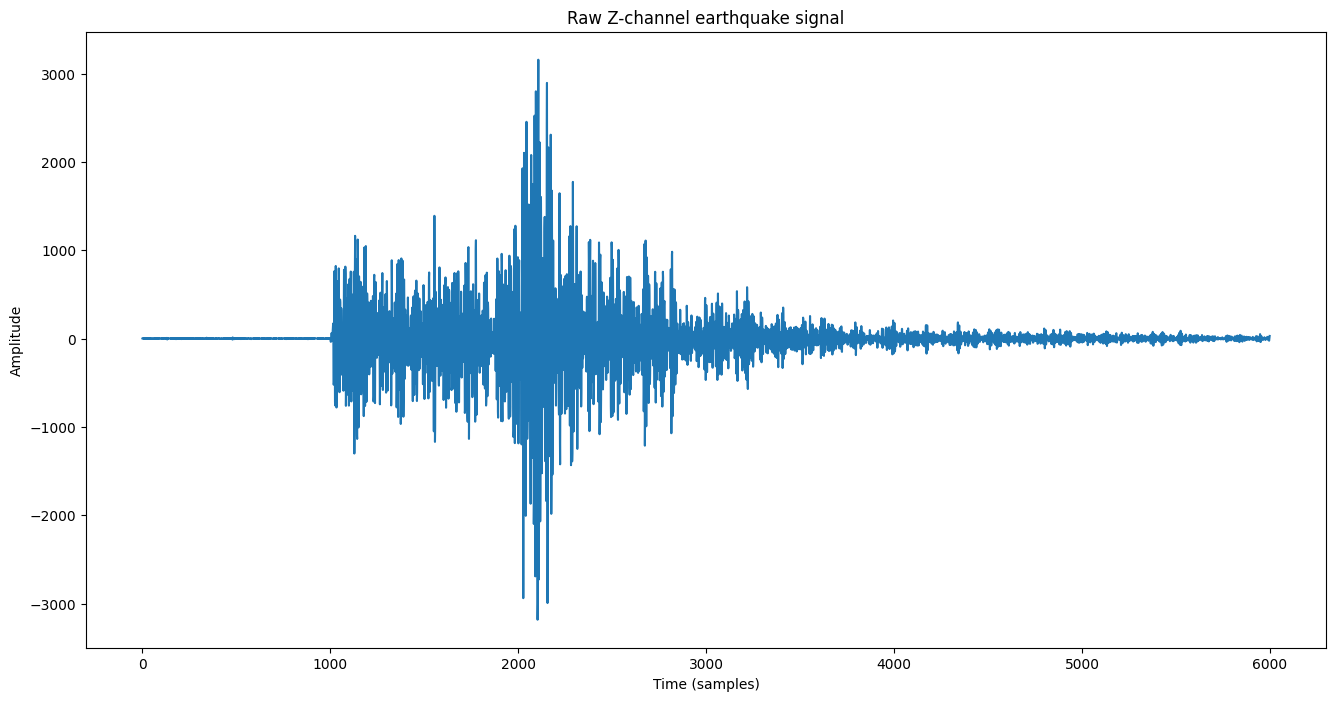

In [14]:
import matplotlib.pyplot as plt

signal = df["Z_channel"].iloc[0]
plt.figure(figsize=(16,8))
plt.plot(signal)
plt.title("Raw Z-channel earthquake signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()


#### In above figure we see that:
##### - X axis(0 ---> 6000) represent time moving forward(moment by moment)
##### - Y axis(Up and Down) represent up and down how much the ground moved up/down at that moment


### MARKING P and S arrival

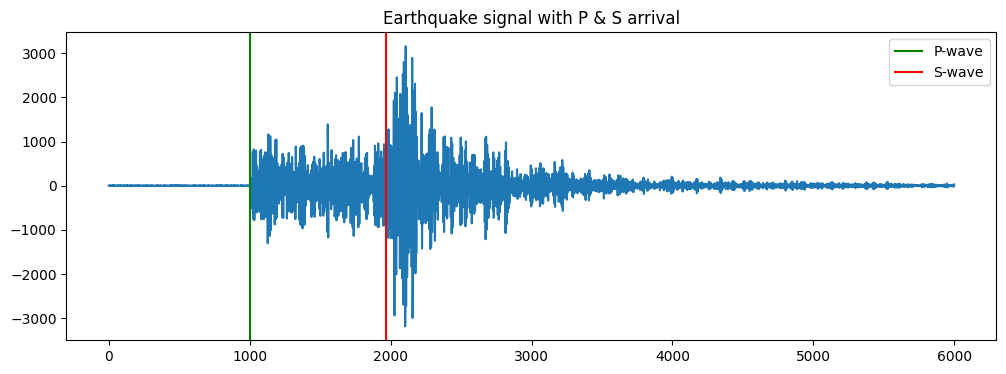

In [15]:
p = df["p_arrival_sample"].iloc[0]
s = df["s_arrival_sample"].iloc[0]

plt.figure(figsize=(12,4))
plt.plot(signal)
plt.axvline(p, color="green", label="P-wave")
plt.axvline(s, color="red", label="S-wave")
plt.legend()
plt.title("Earthquake signal with P & S arrival")
plt.show()



# For Baseline Model (Regression Model)


In [16]:
# Scipy is a scientific library of python,Signal is subset of that library for waves/signals ,butter creates a butterworth filter(a kind
# of filter ) filfit applies the filter backward + forward

from scipy.signal import butter, filtfilt

# sr is sampling rate low removes anything below 1hz high remove anything above 20hz, simplest idea keep shaking between 1-20 hz throw away
# rest of the shit

def bandpass_filter(signal, sr=100, low=1, high=20):
    nyqf = 0.5 * sr #nyqf is Nyquist Frequency(hald of sampling rate) by half cuz signals from the system can only be trusted upto half the sr rate
    
#creating the filter
    b, a = butter(
        N=4, # it defines the sharpness of the filter
        Wn=[low/nyqf, high/nyqf],
        btype="band"
    )
    return filtfilt(b, a, signal)


In [17]:
# Applying filter to 1 Signal
Raw_Sig = df["Z_channel"].iloc[0]
print(Raw_Sig)
filt_sig = bandpass_filter(Raw_Sig)


[  0.38911662  -0.53874105  -0.5868933  ... -10.392837    17.237906
  29.3945    ]


In [18]:
# Normalizing the signal
import numpy as np

# This function make all the signal values small and controlled

def normalize(signal):
    max_val = np.max(np.abs(signal))
    if max_val == 0:
        return signal  # keep zero signal as-is
    return signal / max_val


# np.abs(signal) - convert all the values to positive
#np.max(np.abs(signal)) - Find the largest value in the Signal




clean_sig = normalize(filt_sig)


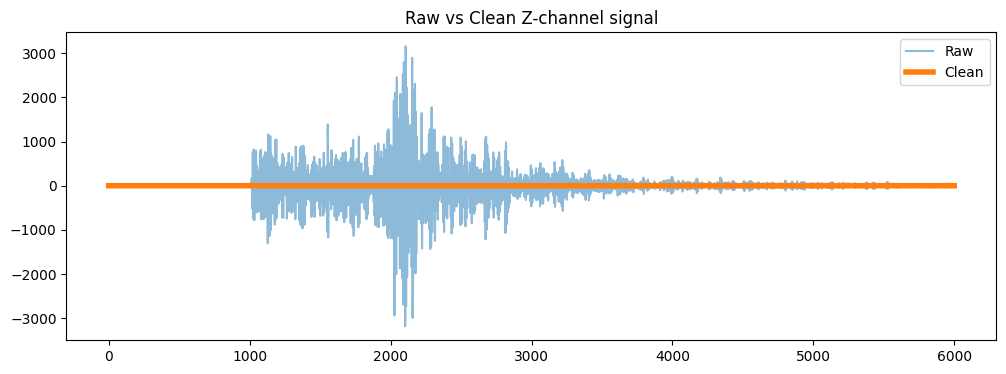

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(Raw_Sig, label="Raw", alpha=0.5)
plt.plot(clean_sig, label="Clean", linewidth=4)
plt.legend()
plt.title("Raw vs Clean Z-channel signal")
plt.show()


In [21]:
#Applying Preprocessing on the whole dataset

def preprocess_signal(signal):
    signal = bandpass_filter(signal)
    signal = normalize(signal)
    return signal

X = np.stack(df["Z_channel"].apply(preprocess_signal).values)

y = df[["p_arrival_sample", "s_arrival_sample"]].values


In [22]:
def extract_features(signal):
    return [
        np.mean(signal),          # average movement
        np.std(signal),           # how shaky-shaky it is
        np.max(signal),           # strongest upward movement
        np.min(signal),           # strongest downward movement
        np.sum(signal**2)         # total energy
    ]


In [23]:
X_new = np.array(
    df["Z_channel"].apply(extract_features).tolist()
)


In [24]:
X_new.shape


(10000, 5)

In [25]:
y_new = df[["p_arrival_sample", "s_arrival_sample"]].values


In [26]:

from sklearn.model_selection import train_test_split

Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42
)


SVR Regressor

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

In [31]:
svr = SVR(
    kernel='rbf',
    C=10,
    epsilon=0.1,
    gamma='scale'
)

model = MultiOutputRegressor(svr)

model.fit(Xb_train, yb_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,SVR(C=10)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


In [33]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(Xb_val)

mae_p = mean_absolute_error(yb_val[:,0], preds[:,0])
mae_s = mean_absolute_error(yb_val[:,1], preds[:,1])

print("Baseline MAE (P-wave):", mae_p)
print("Baseline MAE (S-wave):", mae_s)


Baseline MAE (P-wave): 31.768880490609664
Baseline MAE (S-wave): 310.69359315518557


# PreProcessing

In [34]:
# 1. Drop rows with bad labels
df = df.dropna(subset=["p_arrival_sample", "s_arrival_sample"])

# 2. Remove zero-only signals
df = df[df["Z_channel"].apply(lambda x: np.max(np.abs(x)) > 0)]

print("After cleaning:", len(df))


After cleaning: 10000


In [35]:
TARGET_LEN = 6000  # use your real length

def fix_length(sig):
    if len(sig) > TARGET_LEN:
        return sig[:TARGET_LEN]
    if len(sig) < TARGET_LEN:
        return np.pad(sig, (0, TARGET_LEN - len(sig)))
    return sig

df["Z_channel"] = df["Z_channel"].apply(fix_length)


In [36]:
def normalize_signal(sig):
    max_val = np.max(np.abs(sig))
    if max_val == 0:
        return sig
    return sig / max_val

df["Z_channel"] = df["Z_channel"].apply(normalize_signal)


In [37]:
X = np.array(df["Z_channel"].to_list(), dtype=np.float32)

y = df[["p_arrival_sample", "s_arrival_sample"]].to_numpy(
    dtype=np.float32
)


In [38]:
signal_length = X.shape[1]
y = y / signal_length


In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [40]:
X_train = X_train[:, None, :]
X_val   = X_val[:, None, :]


In [41]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)


In [42]:
class ArrivalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        x = self.features(x)
        return self.fc(x.squeeze(-1))


In [43]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ArrivalCNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [44]:
epochs = 30

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_loss += criterion(preds, yb).item()

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f}"
    )


Epoch 1/30 | Train Loss: 0.0027 | Val Loss: 0.0016
Epoch 2/30 | Train Loss: 0.0015 | Val Loss: 0.0014
Epoch 3/30 | Train Loss: 0.0013 | Val Loss: 0.0013
Epoch 4/30 | Train Loss: 0.0013 | Val Loss: 0.0013
Epoch 5/30 | Train Loss: 0.0013 | Val Loss: 0.0012
Epoch 6/30 | Train Loss: 0.0012 | Val Loss: 0.0013
Epoch 7/30 | Train Loss: 0.0013 | Val Loss: 0.0012
Epoch 8/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 9/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 10/30 | Train Loss: 0.0012 | Val Loss: 0.0014
Epoch 11/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 12/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 13/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 14/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 15/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 16/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 17/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 18/30 | Train Loss: 0.0012 | Val Loss: 0.0013
Epoch 19/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 20/30 | Train L

In [45]:
with torch.no_grad():
    preds = model(X_val_t.to(device)).cpu().numpy()

pred_samples = preds * signal_length
true_samples = y_val * signal_length

mae = np.mean(np.abs(pred_samples - true_samples), axis=0)
print("P MAE:", mae[0], "samples")
print("S MAE:", mae[1], "samples")


P MAE: 54.230446 samples
S MAE: 218.80489 samples
